# Calculate and plot meridional heat transport over time 

## load data locally

Figure S7

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import netCDF4

In [2]:
# get model experiments
def get_experiment_names(model):
    if model == 'FLOR':
        extension = 'tigercpu_intelmpi_18_576PE'
        exps = [
                'p6p0sol_CTL1860',
                'p4p0sol_CTL1860',
                'p2p0sol_CTL1860', 
                'p1p0sol_CTL1860',
                'CTL1860_newdiag',
                'm1p0sol_CTL1860', 
                'm2p0sol_CTL1860',
                'm4p0sol_CTL1860',
                'm6p0sol_CTL1860',
        ]

    if model == 'CM2.1p1':
        extension = 'tigercpu_intelmpi_18_80PE'
        exps = [
                'CTL1860_p6pctSolar', 
                'CTL1860_p4pctSolar',
                'CTL1860_p2pctSolar',
                'CTL1860_p1pctSolar', 
                'CTL1860',
                'CTL1860_m1pctSolar',
                'CTL1860_m2pctSolar',
                'CTL1860_m4pctSolar',
                'CTL1860_m6pctSolar',
                ]
    return exps, extension


In [3]:
# # import data loading function
# import sys
# if '/tigress/wenchang/wython' not in sys.path:
#     sys.path.append('/tigress/wenchang/wython')
    
# from misc.modelout import get_modelout_data, get_modelout_files

import sys
if '/tigress/wenchang/wython/' not in sys.path:
    sys.path.append('/tigress/wenchang/wython/')
    
from modelout.modelout import get_modelout_data, get_modelout_files

In [4]:
#mask = xr.open_dataarray('../Solar/ocean_index_with_ATL_PAC_IND_mod_FIXED_MOC.nc') 
#mask.plot()

In [5]:
def get_mht_atlantic_pacific(da, lat=40):
    # get the mask
    mask = xr.open_dataarray('../Solar/ocean_index_with_ATL_PAC_IND_mod_FIXED_MOC.nc') 
    
    da_masked_atlantic = da.where(mask==1)
    da_masked_IP = da.where((mask == 2) | (mask == 3) | (mask == 4))
    
    # select the latitude of interest, get zonal sum
    mht_atlantic = da_masked_atlantic.sel(lat=lat,method='nearest').sum(('lon'))
    mht_pacific = da_masked_IP.sel(lat=lat,method='nearest').sum(('lon'))
    
    return mht_atlantic, mht_pacific 

# load data and get MHT

In [6]:
latitudes = [40, -40, -55]

In [7]:
models = ['CM2.1p1','FLOR']
func = lambda x: x.load()
funcname = 'output'

for lat in latitudes:
    if lat < 0:
        latstr = f'{lat}S'
    else:
        latstr = f'{lat}N'

    print(f'Computing MHT across {latstr}')

    for model in models:
        exps, extension = get_experiment_names(model)
    
        if model == 'CM2.1p1': var = 'temp_adv_flux_y_int_z'
        if model == 'FLOR': var = 'temp_yflux_adv_int_z'
        
        if model == 'FLOR': dsname = 'ocean'
        elif model == 'CM2.1p1': dsname = 'ocean_month'
        
        for iexp in range(np.size(exps)):
            experiment = f'{exps[iexp]}_{extension}'
    
            if exps[iexp] == 'CTL1860_newdiag' or exps[iexp] == 'CTL1860': # if it's a control experiment,
                n_yrs = 2000 # stop at 2000 years
            else:
                filelist = get_modelout_files(model, experiment, dsname=dsname, ens=None)
                n_yrs = np.shape(filelist)[1]
    
            #n_yrs = 10 # for testing
            data_shape = (n_yrs,) 
    
            # check if the MHT file exists
            import os
            file_path = f'./processed_data/mht_lat{lat}_annavg_ts_Atlantic_{model}_{exps[iexp]}' + '.{0:04d}-{1:04d}.nc' \
                          .format(101,100+n_yrs)
            print(file_path)
            if os.path.exists(file_path):
                print(f'file exists for {model}_{exps[iexp]}')
                continue
            
            # Create an empty DataArray filled with NaNs
            Atlantic_mht_da = xr.DataArray(
                np.full(data_shape, np.nan),  # Fill with NaNs
                dims=["year"],  # Define the dimension
                coords={"year": np.arange(101,101+n_yrs,1)},  # Assign years as the coordinate for the time dimension
                name=f"Atlantic meridional heat transport across {latstr} [W]", # Optional name for the data array
            )
        
            Pacific_mht_da = Atlantic_mht_da.copy()  # Create a copy of the DataArray
            Pacific_mht_da.name = f"Pacific meridional heat transport across {latstr} [W]"  # Rename the DataArray
        
            for iyr in range(n_yrs): # for each year
                year = iyr + 101
                
                # load data
                da_in = get_modelout_data(daname=var, model=model, expname=experiment, 
                                               years=[year], 
                                        func=func, funcname=funcname, dsname=dsname, savedata=False)
                # get MHT for 12 months
                da_in = da_in.rename({'xt_ocean': 'lon', 'yu_ocean': 'lat'})
    
                mht_Atl, mht_Pac = get_mht_atlantic_pacific(da_in, lat)
                
                mht_Atl = mht_Atl.mean('time') # annual average
                mht_Pac = mht_Pac.mean('time')
        
                # save annual average in data array
                Atlantic_mht_da.loc[{"year": year}] = mht_Atl
                Pacific_mht_da.loc[{"year": year}] = mht_Pac
        
            # save populated Atlantic, Pacific arrays
            AMOC_filename = f'./processed_data/mht_lat{lat}_annavg_ts_Atlantic_{model}_{exps[iexp]}' + '.{0:04d}-{1:04d}.nc' \
                          .format(Atlantic_mht_da.year.values[0],Atlantic_mht_da.year.values[-1])
            print(f'{AMOC_filename}')
            PMOC_filename = f'./processed_data/mht_lat{lat}_annavg_ts_IndoPacific_{model}_{exps[iexp]}' + '.{0:04d}-{1:04d}.nc' \
                          .format(Pacific_mht_da.year.values[0],Pacific_mht_da.year.values[-1])
            print(f'{PMOC_filename}')
    
            print('saving Atlantic MHT...')
            Atlantic_mht_da.to_netcdf(AMOC_filename)
            print('saving Pacific MHT...')
            Pacific_mht_da.to_netcdf(PMOC_filename)


Computing MHT across 40N
./processed_data/mht_lat40_annavg_ts_Atlantic_CM2.1p1_CTL1860_p6pctSolar.0101-0310.nc
file exists for CM2.1p1_CTL1860_p6pctSolar
./processed_data/mht_lat40_annavg_ts_Atlantic_CM2.1p1_CTL1860_p4pctSolar.0101-2000.nc
file exists for CM2.1p1_CTL1860_p4pctSolar
./processed_data/mht_lat40_annavg_ts_Atlantic_CM2.1p1_CTL1860_p2pctSolar.0101-1100.nc
file exists for CM2.1p1_CTL1860_p2pctSolar
./processed_data/mht_lat40_annavg_ts_Atlantic_CM2.1p1_CTL1860_p1pctSolar.0101-0300.nc
file exists for CM2.1p1_CTL1860_p1pctSolar
./processed_data/mht_lat40_annavg_ts_Atlantic_CM2.1p1_CTL1860.0101-2100.nc
file exists for CM2.1p1_CTL1860
./processed_data/mht_lat40_annavg_ts_Atlantic_CM2.1p1_CTL1860_m1pctSolar.0101-0300.nc
file exists for CM2.1p1_CTL1860_m1pctSolar
./processed_data/mht_lat40_annavg_ts_Atlantic_CM2.1p1_CTL1860_m2pctSolar.0101-1100.nc
file exists for CM2.1p1_CTL1860_m2pctSolar
./processed_data/mht_lat40_annavg_ts_Atlantic_CM2.1p1_CTL1860_m4pctSolar.0101-2000.nc
file exi

# plot

In [8]:
import os

def find_files_starting_with(directory, start_string):
    files = [
        file for file in os.listdir(directory)
        if os.path.isfile(os.path.join(directory, file)) and file.startswith(start_string)
    ]
    if np.size(files) > 1:
        #print('Multiple files found')
        files = files[0]
    elif np.size(files) < 1:
        #print('No files found')
        files = []
    else:
        files = files[0]
    return files

In [9]:
def get_color_label(experiment):
    if 'p6' in experiment: color, label = 'darkred', '+6%'
    elif 'p4' in experiment: color, label = 'red', '+4%'
    elif 'p2' in experiment: color, label = 'orange', '+2%'
    elif 'p1' in experiment: color, label = 'gold', '+1%'
    elif 'm1' in experiment: color, label = 'cyan', '-1%'
    elif 'm2' in experiment: color, label = 'dodgerblue', '-2%'
    elif 'm4' in experiment: color, label = 'blue', '-4%'
    elif 'm6' in experiment: color, label = 'darkblue', '-6%'
    else: color, label = 'grey', 'CTRL'

    return color, label

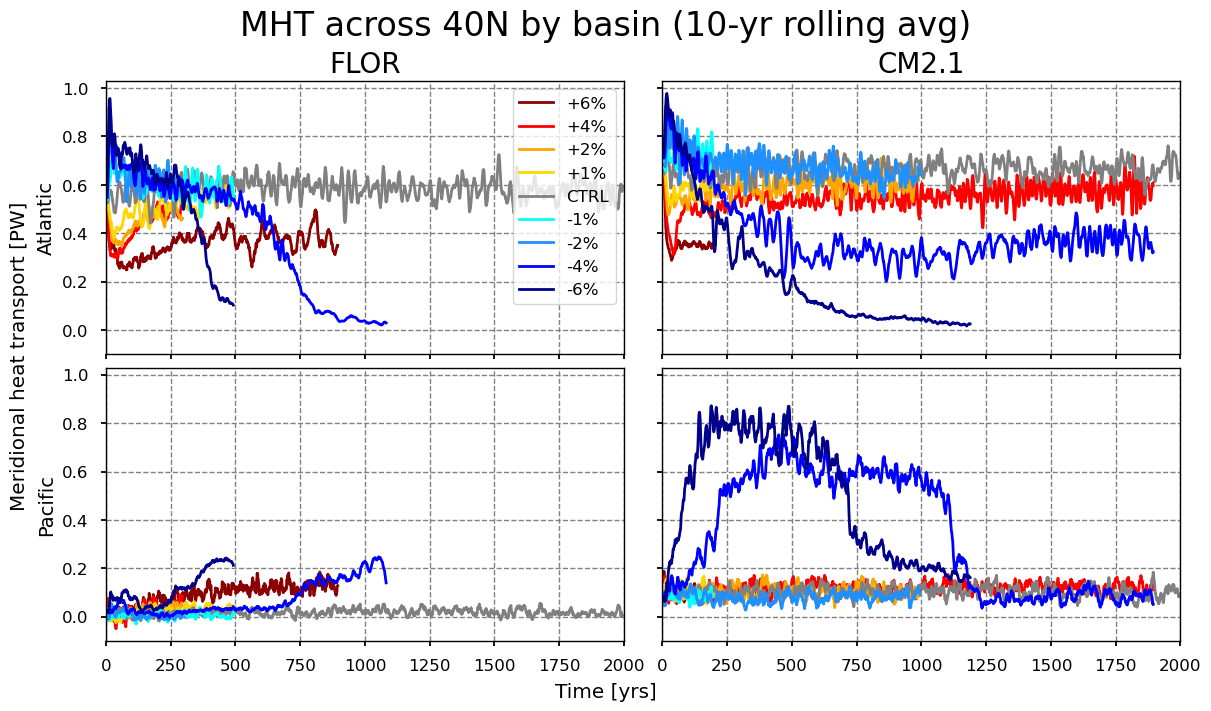

In [20]:
models = ['FLOR','CM2.1p1']
dir_in = '/tigress/mvchung/ANALYSIS/Solar_NEW/processed_data/'
basins = ['Atlantic','IndoPacific']
basin_names = ['Atlantic','Pacific']

plt.style.use('../func/paper.mplstyle')

window = 10 # years for rolling mean

fig, ax = plt.subplots(np.size(basins), 2, figsize=(12,7), sharey = True, sharex=True)

for imodel in range(2):
    model = models[imodel]
    
    exps, extension = get_experiment_names(model)

    for ib in range(np.size(basins)): # for each basin
        
        basin = basins[ib]
        ax[ib,imodel].set_ylabel(basin_names[ib])
            
        for iexp in range(np.size(exps)): # for each experiment
            
            experiment = exps[iexp]
            
            start_string = f'mht_lat40_annavg_ts_{basin}_{model}_{experiment}.' # find the file name based on the basin, experiment and model
            file_in = find_files_starting_with(dir_in, start_string)
            if np.size(file_in) == 0: # if no file exists
                continue

            MHT = xr.open_dataarray(f'{dir_in}/{file_in}') # open the file

            color, label = get_color_label(experiment)
            ax[ib,imodel].plot(MHT.rolling(year=window, center=True).mean('year')*1e-15,color=color,label=label) # plot timeseries

    ax[0,0].legend()
        
    fig.suptitle(f'MHT across 40N by basin ({window}-yr rolling avg)')
    fig.supylabel('Meridional heat transport [PW]')
    fig.supxlabel('Time [yrs]')
    for axis in ax.flatten():
        axis.grid('--')

ax[0,0].set_title('FLOR')
ax[0,1].set_title('CM2.1')
ax[0,1].set_ylabel('')
ax[1,1].set_ylabel('')
ax[0,0].set_xlim(0,2000)

plt.savefig('FigureS7.pdf')